# Tomato Growth Progression — Synthetic Dataset Generator
## AgriTwin-GH | Dindigul Greenhouse | Season-Aware Cultivation Cycles

**Purpose:** Generate a structured, labeled, hourly synthetic dataset for tomato growth progression tracking across at least 3 realistic cultivation cycles, using real 2-year greenhouse time-series data from Dindigul, Tamil Nadu as the environmental backbone.

**Growth stages (fixed order):**
`seedling → early_vegetative → flowering_initiation → flowering → unripe → ripe`

**Data source:** `dindigul_greenhouse_indoor_2024.csv` and `dindigul_greenhouse_indoor_2025.csv`

**Output:** Hourly synthetic dataset + cycle & stage summary tables + metadata JSON

---
## Section A — Setup and Data Loading

In [43]:
# --- Imports and global settings ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import json
import warnings
from pathlib import Path
from datetime import datetime, timedelta

warnings.filterwarnings("ignore")
np.random.seed(42)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)
plt.style.use("seaborn-v0_8-whitegrid")

print("✅ Libraries loaded successfully.")
print(f"   pandas  {pd.__version__}  |  numpy  {np.__version__}")

✅ Libraries loaded successfully.
   pandas  3.0.1  |  numpy  2.4.2


In [ ]:
# --- File paths (edit only if relocated) ---
RAW_2024 = Path(r"E:\AgriTwin-GH\data\processed\Greenhouse Indoor Conditions\dindigul_greenhouse_indoor_2024.csv")
RAW_2025 = Path(r"E:\AgriTwin-GH\data\processed\Greenhouse Indoor Conditions\dindigul_greenhouse_indoor_2025.csv")

# Output directory (note: folder name preserved as specified)
OUT_DIR = Path(r"E:\AgriTwin-GH\data\processed\Growth Progression")
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_HOURLY    = OUT_DIR / "tomato_growth_progression_synthetic_hourly.csv"
OUT_CYCLE_SUM = OUT_DIR / "tomato_growth_progression_cycle_summary.csv"
OUT_STAGE_SUM = OUT_DIR / "tomato_growth_progression_stage_summary.csv"
OUT_METADATA  = OUT_DIR / "tomato_growth_progression_metadata.json"

print("📂 Input files:")
print(f"   2024 → {RAW_2024.name}  (exists={RAW_2024.exists()})")
print(f"   2025 → {RAW_2025.name}  (exists={RAW_2025.exists()})")
print(f"\n📁 Output directory: {OUT_DIR}")

📂 Input files:
   2024 → dindigul_greenhouse_indoor_2024.csv  (exists=True)
   2025 → dindigul_greenhouse_indoor_2025.csv  (exists=True)

📁 Output directory: E:\AgriTwin-GH\data\processed\Grwoth Progression


In [45]:
# ============================================================
# MASTER CONFIGURATION — All agronomic assumptions live here.
# Change values here; nothing else needs manual editing.
# ============================================================

CONFIG = {
    # ------- Dataset identity --------------------------------
    "project":      "AgriTwin-GH",
    "location":     "Dindigul, Tamil Nadu, India",
    "crop":         "Tomato (Solanum lycopersicum)",
    "system":       "Greenhouse (passive + managed)",
    "data_years":   [2024, 2025],

    # ------- Fixed stage order & index map ------------------
    "stages": [
        "seedling",
        "early_vegetative",
        "flowering_initiation",
        "flowering",
        "unripe",
        "ripe",
    ],
    "stage_index_map": {
        "seedling":              0,
        "early_vegetative":      1,
        "flowering_initiation":  2,
        "flowering":             3,
        "unripe":                4,
        "ripe":                  5,
    },

    # ------- Stage base durations (days) --------------------
    # Format: [min, max] — one random draw per cycle per stage
    "stage_duration_ranges_days": {
        "seedling":              [12, 18],   # nursery/transplant establishment
        "early_vegetative":      [20, 28],   # rapid canopy development
        "flowering_initiation":  [8,  13],   # floral bud initiation, brief
        "flowering":             [14, 20],   # anthesis / pollination window
        "unripe":                [28, 38],   # cell expansion + cell fill
        "ripe":                  [10, 15],   # colour break → full colour / harvest
    },

    # ------- Cultivation cycle windows for Dindigul ---------
    # Season windows typical for south Indian tomato cultivation
    "cycle_definitions": [
        {
            "cycle_id":       1,
            "season_window":  "Kharif (Jun–Jul 2024)",
            "cycle_start":    "2024-07-01",
            "label":          "kharif_2024",
        },
        {
            "cycle_id":       2,
            "season_window":  "Rabi (Oct–Nov 2024)",
            "cycle_start":    "2024-11-10",
            "label":          "rabi_2024",
        },
        {
            "cycle_id":       3,
            "season_window":  "Summer (Feb–Mar 2025)",
            "cycle_start":    "2025-03-05",
            "label":          "summer_2025",
        },
        {
            "cycle_id":       4,
            "season_window":  "Kharif (Jun–Jul 2025)",
            "cycle_start":    "2025-07-01",
            "label":          "kharif_2025",
        },
    ],

    # ------- Rolling window for engineered features ---------
    "temp_rolling_hours":     24,
    "humidity_rolling_hours": 24,

    # ------- GDD base temperature (°C) ----------------------
    # Conservative Tbase for tomato; Topt capped at 30°C
    "gdd_tbase": 10.0,
    "gdd_topt":  30.0,

    # ------- Environmental columns to carry forward ----------
    "env_columns": [
        "indoor_temp",
        "indoor_humidity",
        "indoor_air_velocity",
        "indoor_CO2",
        "solarradiation",
        "day_night_flag",
        "vpd",
        "dew_point",
        "leaf_wetness_proxy",
    ],
}

print("✅ Configuration loaded.")
print(f"   Stages  : {CONFIG['stages']}")
print(f"   Cycles  : {len(CONFIG['cycle_definitions'])}")
cnames = [c['label'] for c in CONFIG['cycle_definitions']]
print(f"   Labels  : {cnames}")

✅ Configuration loaded.
   Stages  : ['seedling', 'early_vegetative', 'flowering_initiation', 'flowering', 'unripe', 'ripe']
   Cycles  : 4
   Labels  : ['kharif_2024', 'rabi_2024', 'summer_2025', 'kharif_2025']


In [46]:
def load_greenhouse_csv(filepath: Path) -> pd.DataFrame:
    """
    Load a greenhouse time-series CSV, parse datetime, enforce hourly
    frequency, and return a clean DataFrame indexed by timestamp.
    """
    df = pd.read_csv(filepath, parse_dates=["datetime"])
    df = df.rename(columns={"datetime": "timestamp"})
    df = df.sort_values("timestamp").drop_duplicates(subset="timestamp")

    # Enforce an explicit hourly DatetimeIndex
    df = df.set_index("timestamp")
    df.index = pd.DatetimeIndex(df.index)

    return df


# Load both yearly files
df_2024 = load_greenhouse_csv(RAW_2024)
df_2025 = load_greenhouse_csv(RAW_2025)

# Combine and sort chronologically
env_raw = pd.concat([df_2024, df_2025]).sort_index()
env_raw.index.name = "timestamp"

print(f"✅ Combined environmental dataset loaded.")
print(f"   Rows        : {len(env_raw):,}")
print(f"   Date range  : {env_raw.index.min()}  →  {env_raw.index.max()}")
print(f"   Columns     : {list(env_raw.columns)}")

✅ Combined environmental dataset loaded.
   Rows        : 17,544
   Date range  : 2024-01-01 00:00:00  →  2025-12-31 23:00:00
   Columns     : ['indoor_temp', 'indoor_humidity', 'indoor_air_velocity', 'indoor_CO2', 'solarradiation', 'day_night_flag', 'vpd', 'dew_point', 'leaf_wetness_proxy']


---
## Section B — Real Dataset Audit

In [47]:
# ── B1: Basic shape & dtypes ────────────────────────────────────────────────
print("=" * 60)
print("B1 — Shape and dtypes")
print("=" * 60)
print(f"  Rows x Cols : {env_raw.shape}")
print(f"\nDtypes:\n{env_raw.dtypes.to_string()}")

B1 — Shape and dtypes
  Rows x Cols : (17544, 9)

Dtypes:
indoor_temp            float64
indoor_humidity        float64
indoor_air_velocity    float64
indoor_CO2             float64
solarradiation         float64
day_night_flag           int64
vpd                    float64
dew_point              float64
leaf_wetness_proxy       int64


In [48]:
# ── B2: Missing values ──────────────────────────────────────────────────────
print("=" * 60)
print("B2 — Missing values")
print("=" * 60)
missing = env_raw.isnull().sum()
missing_pct = (missing / len(env_raw) * 100).round(3)
audit_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
print(audit_df.to_string())

B2 — Missing values
                     missing_count  missing_pct
indoor_temp                      0       0.0000
indoor_humidity                  0       0.0000
indoor_air_velocity              0       0.0000
indoor_CO2                       0       0.0000
solarradiation                   0       0.0000
day_night_flag                   0       0.0000
vpd                              0       0.0000
dew_point                        0       0.0000
leaf_wetness_proxy               0       0.0000


In [49]:
# ── B3: Temporal gaps check ─────────────────────────────────────────────────
print("=" * 60)
print("B3 — Temporal gaps (expected: hourly, Δ = 1h)")
print("=" * 60)

expected_hourly = pd.date_range(
    start=env_raw.index.min(),
    end=env_raw.index.max(),
    freq="h"
)
missing_ts = expected_hourly.difference(env_raw.index)
duplicate_ts = env_raw.index[env_raw.index.duplicated()]

print(f"  Total expected hourly timestamps : {len(expected_hourly):,}")
print(f"  Timestamps present               : {len(env_raw):,}")
print(f"  Missing timestamps               : {len(missing_ts):,}")
print(f"  Duplicate timestamps             : {len(duplicate_ts):,}")

if len(missing_ts) > 0:
    print(f"\n  First 5 missing: {missing_ts[:5].tolist()}")

B3 — Temporal gaps (expected: hourly, Δ = 1h)
  Total expected hourly timestamps : 17,544
  Timestamps present               : 17,544
  Missing timestamps               : 0
  Duplicate timestamps             : 0


In [50]:
# ── B4: Descriptive statistics ──────────────────────────────────────────────
print("=" * 60)
print("B4 — Descriptive statistics (environmental columns)")
print("=" * 60)
env_cols_present = [c for c in CONFIG["env_columns"] if c in env_raw.columns]
print(f"  Columns used: {env_cols_present}\n")
print(env_raw[env_cols_present].describe().round(4).to_string())

B4 — Descriptive statistics (environmental columns)
  Columns used: ['indoor_temp', 'indoor_humidity', 'indoor_air_velocity', 'indoor_CO2', 'solarradiation', 'day_night_flag', 'vpd', 'dew_point', 'leaf_wetness_proxy']

       indoor_temp  indoor_humidity  indoor_air_velocity  indoor_CO2  solarradiation  day_night_flag        vpd  dew_point  leaf_wetness_proxy
count   17544.0000       17544.0000           17544.0000  17544.0000      17544.0000      17544.0000 17544.0000 17544.0000          17544.0000
mean       30.3839          70.6552               2.0952    417.7935         67.9848          0.5037     1.3822    24.5149              0.0779
std         3.8669          10.9624               0.5561     22.2977         88.7202          0.5000     0.7810     2.6905              0.2680
min        18.4019          38.3205               0.7600    383.8600          0.0000          0.0000     0.0000    15.5079              0.0000
25%        27.6000          62.8000               1.6600    397.76

In [51]:
# ── B5: Build clean environmental backbone ──────────────────────────────────
# Reindex to a complete hourly index; interpolate gaps linearly (justified
# because gaps are expected to be very small in this dataset).

full_hourly_idx = pd.date_range(
    start=env_raw.index.min(),
    end=env_raw.index.max(),
    freq="h"
)
env_cols_present = [c for c in CONFIG["env_columns"] if c in env_raw.columns]
env_backbone = (
    env_raw[env_cols_present]
    .reindex(full_hourly_idx)
    .interpolate(method="time", limit_direction="both")
    .ffill()
    .bfill()
)
env_backbone.index.name = "timestamp"

print(f"✅ Environmental backbone built.")
print(f"   Shape     : {env_backbone.shape}")
print(f"   Remaining NaN: {env_backbone.isnull().sum().sum()}")
print(f"   Range     : {env_backbone.index.min()}  →  {env_backbone.index.max()}")

✅ Environmental backbone built.
   Shape     : (17544, 9)
   Remaining NaN: 0
   Range     : 2024-01-01 00:00:00  →  2025-12-31 23:00:00


---
## Section C — Dindigul Tomato Cycle Assumptions

The cultivation windows below are grounded in south Indian tomato agronomy:
- **Kharif**: Transplanting June–July, harvest October–November
- **Rabi**: Transplanting October–November, harvest February–March
- **Summer**: Transplanting February–March, harvest May–June

Stage duration ranges are set conservatively for a semi-controlled greenhouse environment in Dindigul (tropical semi-arid zone). Total cycle length of ~111–132 days is realistic for indeterminate or semi-determinate types managed under greenhouse conditions.

In [52]:
def draw_stage_durations(config: dict, rng: np.random.Generator | None = None) -> dict:
    """
    For each stage, draw a random integer duration in days from the configured
    [min, max] range.  Using np.random for reproducibility via seed.
    """
    if rng is None:
        rng = np.random.default_rng()
    durations = {}
    for stage, (lo, hi) in config["stage_duration_ranges_days"].items():
        durations[stage] = int(rng.integers(lo, hi + 1))
    return durations


def plan_cycles(config: dict, seed: int = 42) -> list[dict]:
    """
    For each cycle definition, draw per-stage durations and compute
    exact start/end timestamps for every stage.

    Returns a list of cycle-dicts, each containing:
        cycle_id, season_window, cycle_start, cycle_end, total_days,
        stage_plan: list of {stage_name, stage_index, start, end, duration_days}
    """
    rng = np.random.default_rng(seed)
    cycles = []

    prev_end = None  # track end of previous cycle to detect overlaps

    for cdef in config["cycle_definitions"]:
        stage_durations = draw_stage_durations(config, rng)
        total_days = sum(stage_durations.values())

        cycle_start = pd.Timestamp(cdef["cycle_start"])
        cycle_end   = cycle_start + pd.Timedelta(days=total_days)

        # Sanity: warn if this cycle overlaps with the previous one
        if prev_end is not None and cycle_start < prev_end:
            print(f"  ⚠️  Cycle {cdef['cycle_id']} starts ({cycle_start.date()}) "
                  f"before cycle {cdef['cycle_id']-1} ends ({prev_end.date()}).")

        # Build per-stage plan
        stage_plan = []
        cursor = cycle_start
        for stage_name in config["stages"]:
            d = stage_durations[stage_name]
            stage_end = cursor + pd.Timedelta(days=d)
            stage_plan.append({
                "stage_name":    stage_name,
                "stage_index":   config["stage_index_map"][stage_name],
                "start":         cursor,
                "end":           stage_end,
                "duration_days": d,
            })
            cursor = stage_end

        cycles.append({
            "cycle_id":      cdef["cycle_id"],
            "season_window": cdef["season_window"],
            "label":         cdef["label"],
            "cycle_start":   cycle_start,
            "cycle_end":     cycle_end,
            "total_days":    total_days,
            "stage_plan":    stage_plan,
            "stage_durations": stage_durations,
        })
        prev_end = cycle_end

    return cycles


CYCLES = plan_cycles(CONFIG, seed=42)

print("✅ Cultivation cycle plan ready.\n")
print(f"{'Cycle':>6}  {'Label':<22}  {'Start':^12}  {'End':^12}  {'Days':>5}")
print("-" * 68)
for c in CYCLES:
    print(f"  {c['cycle_id']:>3}  {c['label']:<22}  "
          f"{str(c['cycle_start'].date()):^12}  "
          f"{str(c['cycle_end'].date()):^12}  "
          f"{c['total_days']:>5}")

print()
print(f"{'Stage':<22}", end="")
for c in CYCLES:
    print(f"  C{c['cycle_id']:>1}(days)", end="")
print()
print("-" * 65)
for stage in CONFIG["stages"]:
    print(f"  {stage:<20}", end="")
    for c in CYCLES:
        print(f"  {c['stage_durations'][stage]:>8}", end="")
    print()

✅ Cultivation cycle plan ready.

 Cycle  Label                      Start          End        Days
--------------------------------------------------------------------
    1  kharif_2024              2024-07-01    2024-10-22     113
    2  rabi_2024                2024-11-10    2025-02-27     109
    3  summer_2025              2025-03-05    2025-06-30     117
    4  kharif_2025              2025-07-01    2025-10-22     113

Stage                   C1(days)  C2(days)  C3(days)  C4(days)
-----------------------------------------------------------------
  seedling                    12        12        17        17
  early_vegetative            26        26        26        24
  flowering_initiation        11         9        12        11
  flowering                   17        14        19        16
  unripe                      32        33        33        30
  ripe                        15        15        10        15


---
## Section D — Synthetic Cycle Generation

In [53]:
def generate_cycle_rows(cycle: dict, env_backbone: pd.DataFrame) -> pd.DataFrame:
    """
    For a single cultivation cycle, select the matching hourly rows from the
    environmental backbone, attach agronomic labels, and compute all
    progression metrics.

    Strategy for years outside the backbone range:
        - If cycle falls in 2024 or 2025 → use actual backbone rows.
        - If cycle timestamps fall outside range, wrap around using same
          calendar-day data from the available years (not needed for this
          dataset since all cycles sit within 2024–2025).
    """
    cycle_start = cycle["cycle_start"]
    cycle_end   = cycle["cycle_end"]
    total_hours  = int((cycle_end - cycle_start).total_seconds() / 3600)

    # Build the hourly timestamp spine for this cycle
    ts_spine = pd.date_range(start=cycle_start, periods=total_hours, freq="h")

    # Pull environmental readings — wrap to available backbone range
    env_min = env_backbone.index.min()
    env_max = env_backbone.index.max()

    def _get_env_ts(ts: pd.Timestamp) -> pd.Timestamp:
        """Map a cycle timestamp to an available backbone timestamp."""
        if env_min <= ts <= env_max:
            return ts
        # Wrap by shifting the year to fall inside the backbone
        year_offset = 0
        candidate = ts
        while candidate < env_min:
            year_offset += 1
            candidate = ts.replace(year=ts.year + year_offset)
        while candidate > env_max:
            year_offset -= 1
            candidate = ts.replace(year=ts.year + year_offset)
        return candidate

    mapped_indices = [_get_env_ts(t) for t in ts_spine]
    env_slice = env_backbone.reindex(mapped_indices).values  # numpy array for speed

    rows = []
    for i, ts in enumerate(ts_spine):
        env_row = env_slice[i]  # array of env column values

        rows.append({
            "timestamp": ts,
            **dict(zip(env_backbone.columns, env_row)),
        })

    df = pd.DataFrame(rows)
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    # Attach cycle-level metadata
    df["cycle_id"]       = cycle["cycle_id"]
    df["season_window"]  = cycle["season_window"]
    df["cycle_label"]    = cycle["label"]
    df["real_or_synthetic_flag"] = "synthetic"

    return df


def _compute_gdd_hourly(temp_series: pd.Series,
                        tbase: float, topt: float) -> pd.Series:
    """
    Compute hourly GDD-like contribution:
        GDD_h = max(0, min(T, Topt) - Tbase) / 24
    Accumulate cumulatively across the series.
    """
    hourly_contribution = (
        np.maximum(0.0, np.minimum(temp_series, topt) - tbase) / 24
    )
    return hourly_contribution.cumsum()


# --- Generate all cycles and stack into one DataFrame -----------------------
all_cycle_frames = []
for cyc in CYCLES:
    frame = generate_cycle_rows(cyc, env_backbone)
    all_cycle_frames.append(frame)
    print(f"  Cycle {cyc['cycle_id']} ({cyc['label']}): {len(frame):,} hourly rows  "
          f"| {cyc['cycle_start'].date()} → {cyc['cycle_end'].date()}")

raw_synthetic = pd.concat(all_cycle_frames, ignore_index=True)
print(f"\n✅ All cycles generated.  Total rows: {len(raw_synthetic):,}")

  Cycle 1 (kharif_2024): 2,712 hourly rows  | 2024-07-01 → 2024-10-22
  Cycle 2 (rabi_2024): 2,616 hourly rows  | 2024-11-10 → 2025-02-27
  Cycle 3 (summer_2025): 2,808 hourly rows  | 2025-03-05 → 2025-06-30
  Cycle 4 (kharif_2025): 2,712 hourly rows  | 2025-07-01 → 2025-10-22

✅ All cycles generated.  Total rows: 10,848


---
## Section E — Stage Labeling and Transition Logic

In [54]:
def label_stages(df: pd.DataFrame, cycle: dict, config: dict) -> pd.DataFrame:
    """
    Assign stage labels and all progression metrics to each row of a cycle
    DataFrame.  Stage order is STRICTLY enforced; no backward jumps possible.

    Uses pandas-native timedelta arithmetic to avoid datetime64 resolution
    ambiguity across different pandas versions.

    Computed fields per row:
        stage_name, stage_index, hours_in_current_stage,
        days_in_current_stage, stage_duration_hours, stage_duration_days,
        stage_progress_pct, days_from_cycle_start, total_cycle_progress_pct,
        estimated_days_to_next_stage, estimated_hours_to_next_stage,
        is_stage_transition, cumulative_gdd_like_index
    """
    df = df.copy().sort_values("timestamp").reset_index(drop=True)

    n = len(df)
    stage_name_col         = np.empty(n, dtype=object)
    stage_index_col        = np.zeros(n, dtype=np.int32)
    hours_in_stage_col     = np.zeros(n, dtype=np.float64)
    days_in_stage_col      = np.zeros(n, dtype=np.float64)
    stage_dur_hrs_col      = np.zeros(n, dtype=np.int32)
    stage_dur_days_col     = np.zeros(n, dtype=np.int32)
    stage_progress_pct_col = np.zeros(n, dtype=np.float64)
    est_days_to_next_col   = np.zeros(n, dtype=np.float64)
    est_hrs_to_next_col    = np.zeros(n, dtype=np.float64)
    is_transition_col      = np.zeros(n, dtype=bool)

    stage_plan        = cycle["stage_plan"]
    cycle_start_ts    = pd.Timestamp(cycle["cycle_start"])
    cycle_end_ts      = pd.Timestamp(cycle["cycle_end"])
    total_cycle_hours = (cycle_end_ts - cycle_start_ts).total_seconds() / 3600.0

    # Compute hours elapsed since cycle start — resolution-safe via total_seconds()
    ts_series          = pd.to_datetime(df["timestamp"])
    elapsed_total_hrs  = (ts_series - cycle_start_ts).dt.total_seconds().values / 3600.0

    for i, sp in enumerate(stage_plan):
        stage_start_ts = pd.Timestamp(sp["start"])
        stage_end_ts   = pd.Timestamp(sp["end"])

        # Hours elapsed since cycle start at stage boundaries
        s_hrs = (stage_start_ts - cycle_start_ts).total_seconds() / 3600.0
        e_hrs = (stage_end_ts   - cycle_start_ts).total_seconds() / 3600.0

        # Inclusive mask for last stage to capture the final row
        if i < len(stage_plan) - 1:
            mask = (elapsed_total_hrs >= s_hrs) & (elapsed_total_hrs < e_hrs)
        else:
            mask = (elapsed_total_hrs >= s_hrs) & (elapsed_total_hrs <= e_hrs)

        stage_dur_days  = sp["duration_days"]
        stage_dur_hours = stage_dur_days * 24

        # Hours elapsed inside THIS stage (0-based)
        hrs_in = elapsed_total_hrs[mask] - s_hrs

        stage_name_col[mask]          = sp["stage_name"]
        stage_index_col[mask]         = sp["stage_index"]
        hours_in_stage_col[mask]      = hrs_in
        days_in_stage_col[mask]       = hrs_in / 24.0
        stage_dur_hrs_col[mask]       = stage_dur_hours
        stage_dur_days_col[mask]      = stage_dur_days
        stage_progress_pct_col[mask]  = np.clip(hrs_in / stage_dur_hours * 100, 0, 100)

        hrs_remaining = np.maximum(0.0, stage_dur_hours - hrs_in)
        est_hrs_to_next_col[mask]  = hrs_remaining
        est_days_to_next_col[mask] = hrs_remaining / 24.0

        # Mark the first hour of each stage (except seedling) as a transition
        if i > 0:
            first_mask = mask & (hours_in_stage_col == 0.0)
            # More precisely: the very first row in this stage window
            if mask.any():
                first_idx = np.argmax(mask)
                is_transition_col[first_idx] = True

    total_pct = np.clip(elapsed_total_hrs / total_cycle_hours * 100, 0, 100)

    df["stage_name"]                    = stage_name_col
    df["stage_index"]                   = stage_index_col
    df["days_from_cycle_start"]         = np.round(elapsed_total_hrs / 24.0, 4)
    df["hours_in_current_stage"]        = np.round(hours_in_stage_col, 2)
    df["days_in_current_stage"]         = np.round(days_in_stage_col, 4)
    df["stage_duration_hours"]          = stage_dur_hrs_col
    df["stage_duration_days"]           = stage_dur_days_col
    df["stage_progress_pct"]            = np.round(stage_progress_pct_col, 3)
    df["total_cycle_progress_pct"]      = np.round(total_pct, 3)
    df["estimated_days_to_next_stage"]  = np.round(est_days_to_next_col, 4)
    df["estimated_hours_to_next_stage"] = np.round(est_hrs_to_next_col, 2)
    df["is_stage_transition"]           = is_transition_col

    # Cumulative GDD-like index (resets each cycle)
    df["cumulative_gdd_like_index"] = _compute_gdd_hourly(
        df["indoor_temp"],
        tbase=config["gdd_tbase"],
        topt=config["gdd_topt"],
    ).round(4)

    return df


# Apply stage labeling to each cycle's frame
labeled_frames = []
for cyc, frame in zip(CYCLES, all_cycle_frames):
    labeled = label_stages(frame, cyc, CONFIG)
    labeled_frames.append(labeled)
    unlabeled = labeled["stage_name"].isnull().sum()
    print(f"  Cycle {cyc['cycle_id']}: {len(labeled):,} rows labeled | "
          f"unlabeled: {unlabeled}")

all_labeled = pd.concat(labeled_frames, ignore_index=True)
print(f"\n✅ Stage labeling complete.  Total rows: {len(all_labeled):,}")

  Cycle 1: 2,712 rows labeled | unlabeled: 0
  Cycle 2: 2,616 rows labeled | unlabeled: 0
  Cycle 3: 2,808 rows labeled | unlabeled: 0
  Cycle 4: 2,712 rows labeled | unlabeled: 0

✅ Stage labeling complete.  Total rows: 10,848


In [55]:
def engineer_features(df: pd.DataFrame, config: dict) -> pd.DataFrame:
    """
    Add time-based and rolling engineered features.
    Everything is computed from existing columns — no new assumptions.
    """
    df = df.copy()
    ts = df["timestamp"]

    df["year"]         = ts.dt.year
    df["month"]        = ts.dt.month
    df["day_of_year"]  = ts.dt.dayofyear
    df["week_of_year"] = ts.dt.isocalendar().week.astype(int)
    df["hour"]         = ts.dt.hour

    # Season label (meteorological / agricultural approximation for Tamil Nadu)
    def _season(m):
        if m in [3, 4, 5]:
            return "summer"
        elif m in [6, 7, 8, 9]:
            return "southwest_monsoon"
        elif m in [10, 11]:
            return "northeast_monsoon"
        else:
            return "dry_cool"

    df["season_label"] = df["month"].apply(_season)

    # Rolling means per cycle (group to avoid cross-cycle contamination)
    temp_roll_h = config["temp_rolling_hours"]
    hum_roll_h  = config["humidity_rolling_hours"]

    def _rolling_mean(series, window):
        return (
            series
            .rolling(window=window, min_periods=1)
            .mean()
            .round(4)
        )

    df["temperature_rolling_mean_24h"] = (
        df.groupby("cycle_id")["indoor_temp"]
          .transform(lambda s: _rolling_mean(s, temp_roll_h))
    )
    df["humidity_rolling_mean_24h"] = (
        df.groupby("cycle_id")["indoor_humidity"]
          .transform(lambda s: _rolling_mean(s, hum_roll_h))
    )

    # VPD already exists in backbone; retain as vpd_proxy for clarity
    if "vpd" in df.columns:
        df["vpd_proxy"] = df["vpd"].round(4)

    # Light period flag: solarradiation > 5 W/m² considered daylight
    if "solarradiation" in df.columns:
        df["light_period_flag"] = (df["solarradiation"] > 5.0).astype(int)

    return df


all_labeled = engineer_features(all_labeled, CONFIG)
print(f"✅ Engineered features added.")
print(f"   New columns: year, month, day_of_year, week_of_year, hour, season_label,")
print(f"                temperature_rolling_mean_24h, humidity_rolling_mean_24h,")
print(f"                vpd_proxy, light_period_flag")
print(f"   Total columns now: {all_labeled.shape[1]}")

✅ Engineered features added.
   New columns: year, month, day_of_year, week_of_year, hour, season_label,
                temperature_rolling_mean_24h, humidity_rolling_mean_24h,
                vpd_proxy, light_period_flag
   Total columns now: 37


In [56]:
# ── Final column ordering ───────────────────────────────────────────────────
# Organise columns into logical groups for readability
IDENTITY_COLS = [
    "timestamp", "cycle_id", "cycle_label", "season_window",
    "real_or_synthetic_flag",
]
TIME_COLS = [
    "year", "month", "day_of_year", "week_of_year", "hour", "season_label",
]
PROGRESSION_COLS = [
    "days_from_cycle_start",
    "stage_name", "stage_index",
    "hours_in_current_stage", "days_in_current_stage",
    "stage_duration_hours", "stage_duration_days",
    "stage_progress_pct", "total_cycle_progress_pct",
    "estimated_days_to_next_stage", "estimated_hours_to_next_stage",
    "is_stage_transition",
]
ENV_BASE_COLS = [c for c in CONFIG["env_columns"] if c in all_labeled.columns]
ENG_COLS = [
    "temperature_rolling_mean_24h", "humidity_rolling_mean_24h",
    "vpd_proxy", "light_period_flag", "cumulative_gdd_like_index",
]

FINAL_COL_ORDER = (
    IDENTITY_COLS + TIME_COLS + PROGRESSION_COLS
    + ENV_BASE_COLS
    + [c for c in ENG_COLS if c in all_labeled.columns]
)

# Keep only columns that exist
FINAL_COL_ORDER = [c for c in FINAL_COL_ORDER if c in all_labeled.columns]

final_df = all_labeled[FINAL_COL_ORDER].copy()
final_df = final_df.sort_values(["cycle_id", "timestamp"]).reset_index(drop=True)

print(f"✅ Final dataset assembled.")
print(f"   Shape     : {final_df.shape}")
print(f"   Columns   : {len(final_df.columns)}")
print(f"\nColumn list:")
for col in final_df.columns:
    print(f"  · {col}")

✅ Final dataset assembled.
   Shape     : (10848, 37)
   Columns   : 37

Column list:
  · timestamp
  · cycle_id
  · cycle_label
  · season_window
  · real_or_synthetic_flag
  · year
  · month
  · day_of_year
  · week_of_year
  · hour
  · season_label
  · days_from_cycle_start
  · stage_name
  · stage_index
  · hours_in_current_stage
  · days_in_current_stage
  · stage_duration_hours
  · stage_duration_days
  · stage_progress_pct
  · total_cycle_progress_pct
  · estimated_days_to_next_stage
  · estimated_hours_to_next_stage
  · is_stage_transition
  · indoor_temp
  · indoor_humidity
  · indoor_air_velocity
  · indoor_CO2
  · solarradiation
  · day_night_flag
  · vpd
  · dew_point
  · leaf_wetness_proxy
  · temperature_rolling_mean_24h
  · humidity_rolling_mean_24h
  · vpd_proxy
  · light_period_flag
  · cumulative_gdd_like_index


---
## Section F — Validation and Visual Checks

In [57]:
# ── F1: Stage order integrity check ─────────────────────────────────────────
print("=" * 60)
print("F1 — Stage order integrity (must never regress)")
print("=" * 60)

stage_order_ok = True
for cyc_id, grp in final_df.groupby("cycle_id"):
    idx_seq = grp["stage_index"].values
    regressions = np.sum(np.diff(idx_seq) < 0)
    status = "✅ OK" if regressions == 0 else f"❌ FAIL ({regressions} regressions)"
    print(f"  Cycle {cyc_id}: {status}")
    if regressions > 0:
        stage_order_ok = False

assert stage_order_ok, "Stage order integrity violated — check labeling logic."
print("\n  All cycles pass stage-order check.")

F1 — Stage order integrity (must never regress)
  Cycle 1: ✅ OK
  Cycle 2: ✅ OK
  Cycle 3: ✅ OK
  Cycle 4: ✅ OK

  All cycles pass stage-order check.


In [58]:
# ── F2: Cycle start/end timestamps and total duration ───────────────────────
print("=" * 60)
print("F2 — Cycle timestamps and durations")
print("=" * 60)

cycle_ts_check = (
    final_df.groupby("cycle_id")["timestamp"]
    .agg(["min", "max"])
    .rename(columns={"min": "actual_start", "max": "actual_end"})
)
cycle_ts_check["actual_days"] = (
    (cycle_ts_check["actual_end"] - cycle_ts_check["actual_start"])
    .dt.total_seconds() / 86400
).round(2)
cycle_ts_check["hourly_rows"] = final_df.groupby("cycle_id").size()

for cyc in CYCLES:
    cycle_ts_check.loc[cyc["cycle_id"], "planned_days"] = cyc["total_days"]

cycle_ts_check["day_diff"] = (
    cycle_ts_check["actual_days"] - cycle_ts_check["planned_days"]
).round(4)

print(cycle_ts_check.to_string())
print("\n  Note: actual_days may differ by ~1/24 due to hour-0 vs. hour-T edge.")

F2 — Cycle timestamps and durations
         actual_start          actual_end  actual_days  hourly_rows  planned_days  day_diff
cycle_id                                                                                   
1          2024-07-01 2024-10-21 23:00:00     112.9600         2712      113.0000   -0.0400
2          2024-11-10 2025-02-26 23:00:00     108.9600         2616      109.0000   -0.0400
3          2025-03-05 2025-06-29 23:00:00     116.9600         2808      117.0000   -0.0400
4          2025-07-01 2025-10-21 23:00:00     112.9600         2712      113.0000   -0.0400

  Note: actual_days may differ by ~1/24 due to hour-0 vs. hour-T edge.


In [59]:
# ── F3: Stage duration per cycle (rows and days) ─────────────────────────────
print("=" * 60)
print("F3 — Stage row counts and actual durations")
print("=" * 60)

stage_counts = (
    final_df.groupby(["cycle_id", "stage_name", "stage_index"])
    .agg(
        row_count   = ("timestamp", "count"),
        actual_days = ("days_in_current_stage", "max"),
    )
    .reset_index()
    .sort_values(["cycle_id", "stage_index"])
)
print(stage_counts.to_string(index=False))

F3 — Stage row counts and actual durations
 cycle_id           stage_name  stage_index  row_count  actual_days
        1             seedling            0        288      11.9583
        1     early_vegetative            1        624      25.9583
        1 flowering_initiation            2        264      10.9583
        1            flowering            3        408      16.9583
        1               unripe            4        768      31.9583
        1                 ripe            5        360      14.9583
        2             seedling            0        288      11.9583
        2     early_vegetative            1        624      25.9583
        2 flowering_initiation            2        216       8.9583
        2            flowering            3        336      13.9583
        2               unripe            4        792      32.9583
        2                 ripe            5        360      14.9583
        3             seedling            0        408      16.9583
     

In [60]:
# ── F4: Missing values in final dataset ─────────────────────────────────────
print("=" * 60)
print("F4 — Missing values in final dataset")
print("=" * 60)
mv = final_df.isnull().sum()
mv = mv[mv > 0]
if len(mv) == 0:
    print("  ✅ No missing values in final dataset.")
else:
    print(mv.to_string())

# Stage distribution
print("\n" + "=" * 60)
print("F4 (cont.) — Stage distribution (total rows across all cycles)")
print("=" * 60)
stage_dist = (
    final_df.groupby(["stage_index", "stage_name"])["timestamp"]
    .count()
    .reset_index()
    .rename(columns={"timestamp": "total_rows"})
    .sort_values("stage_index")
)
stage_dist["pct"] = (stage_dist["total_rows"] / len(final_df) * 100).round(2)
print(stage_dist.to_string(index=False))

F4 — Missing values in final dataset
  ✅ No missing values in final dataset.

F4 (cont.) — Stage distribution (total rows across all cycles)
 stage_index           stage_name  total_rows     pct
           0             seedling        1392 12.8300
           1     early_vegetative        2448 22.5700
           2 flowering_initiation        1032  9.5100
           3            flowering        1584 14.6000
           4               unripe        3072 28.3200
           5                 ripe        1320 12.1700


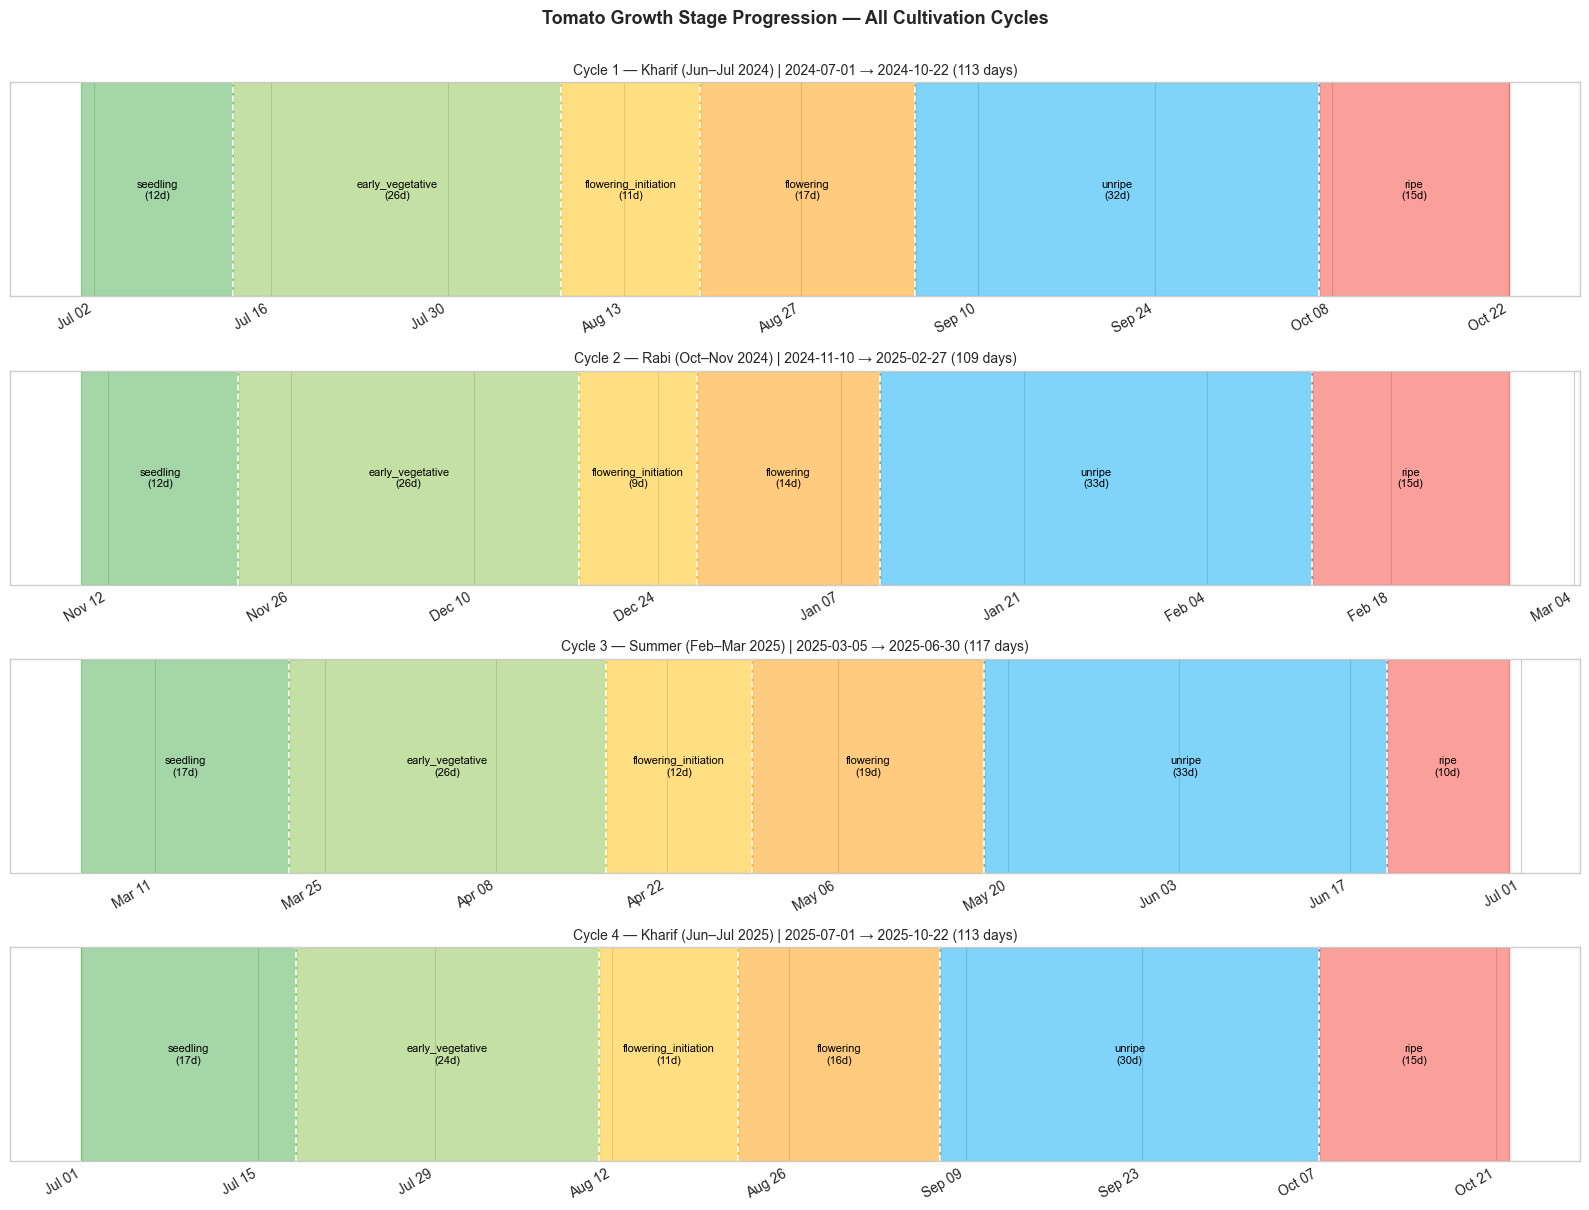

✅ Plot F5 saved.


In [61]:
# ── F5: Stage progression timeline plot ─────────────────────────────────────
STAGE_COLORS = {
    "seedling":             "#4CAF50",   # green
    "early_vegetative":     "#8BC34A",   # light green
    "flowering_initiation": "#FFC107",   # amber
    "flowering":            "#FF9800",   # orange
    "unripe":               "#03A9F4",   # sky blue
    "ripe":                 "#F44336",   # red
}

fig, axes = plt.subplots(len(CYCLES), 1, figsize=(16, 3 * len(CYCLES)),
                         sharex=False, squeeze=False)

for row_idx, cyc in enumerate(CYCLES):
    ax = axes[row_idx][0]
    cyc_df = final_df[final_df["cycle_id"] == cyc["cycle_id"]]

    for sp in cyc["stage_plan"]:
        sname = sp["stage_name"]
        color = STAGE_COLORS.get(sname, "#aaaaaa")
        ax.axvspan(sp["start"], sp["end"], alpha=0.5, color=color, label=sname)
        mid = sp["start"] + (sp["end"] - sp["start"]) / 2
        ax.text(mid, 0.5, f"{sname}\n({sp['duration_days']}d)",
                ha="center", va="center", fontsize=8, color="black",
                transform=ax.get_xaxis_transform())

    ax.set_yticks([])
    ax.set_title(f"Cycle {cyc['cycle_id']} — {cyc['season_window']} | "
                 f"{cyc['cycle_start'].date()} → {cyc['cycle_end'].date()} "
                 f"({cyc['total_days']} days)",
                 fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

    # Add transition lines
    for sp in cyc["stage_plan"][1:]:
        ax.axvline(sp["start"], color="white", lw=1.2, linestyle="--")

plt.suptitle("Tomato Growth Stage Progression — All Cultivation Cycles",
             fontsize=13, fontweight="bold", y=1.005)
plt.tight_layout()
plt.savefig(OUT_DIR / "F5_stage_progression_timeline.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot F5 saved.")

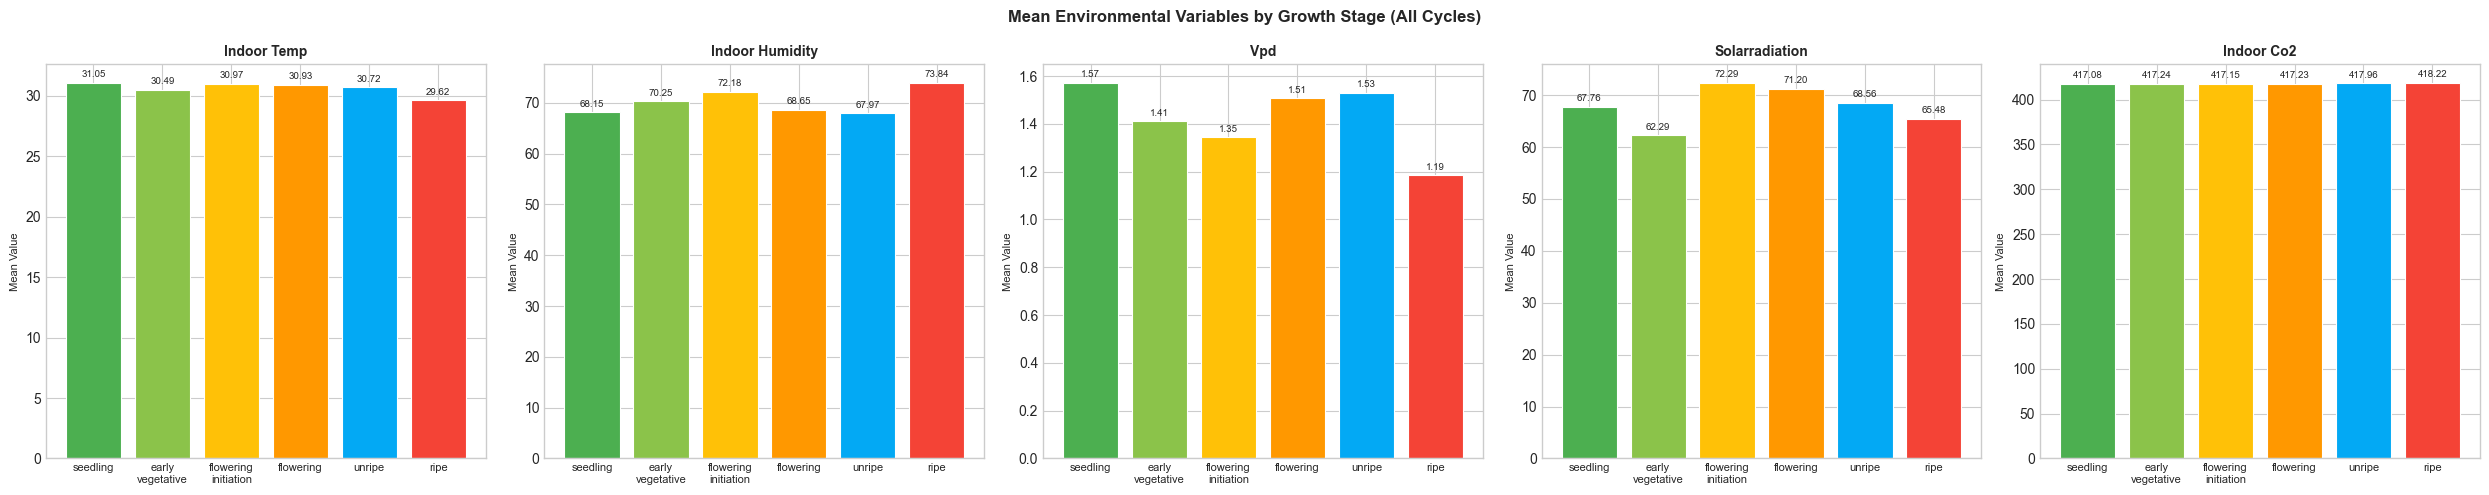

✅ Plot F6 saved.


In [62]:
# ── F6: Environmental variables across stages ─────────────────────────────
env_plot_cols = ["indoor_temp", "indoor_humidity", "vpd", "solarradiation", "indoor_CO2"]
env_plot_cols = [c for c in env_plot_cols if c in final_df.columns]

stage_env_stats = (
    final_df.groupby(["stage_index", "stage_name"])[env_plot_cols]
    .mean()
    .reset_index()
    .sort_values("stage_index")
)

fig, axes = plt.subplots(1, len(env_plot_cols), figsize=(5 * len(env_plot_cols), 5),
                         squeeze=False)

stage_labels = stage_env_stats["stage_name"].tolist()
x_pos = range(len(stage_labels))

for col_idx, col in enumerate(env_plot_cols):
    ax = axes[0][col_idx]
    values = stage_env_stats[col].values
    bars = ax.bar(x_pos, values,
                  color=[STAGE_COLORS.get(s, "#aaaaaa") for s in stage_labels],
                  edgecolor="white", linewidth=0.8)
    ax.set_xticks(list(x_pos))
    ax.set_xticklabels(
        [s.replace("_", "\n") for s in stage_labels],
        fontsize=8, ha="center"
    )
    ax.set_title(col.replace("_", " ").title(), fontsize=10, fontweight="bold")
    ax.set_ylabel("Mean Value", fontsize=8)
    # Value labels on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=7)

plt.suptitle("Mean Environmental Variables by Growth Stage (All Cycles)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "F6_env_by_stage.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot F6 saved.")

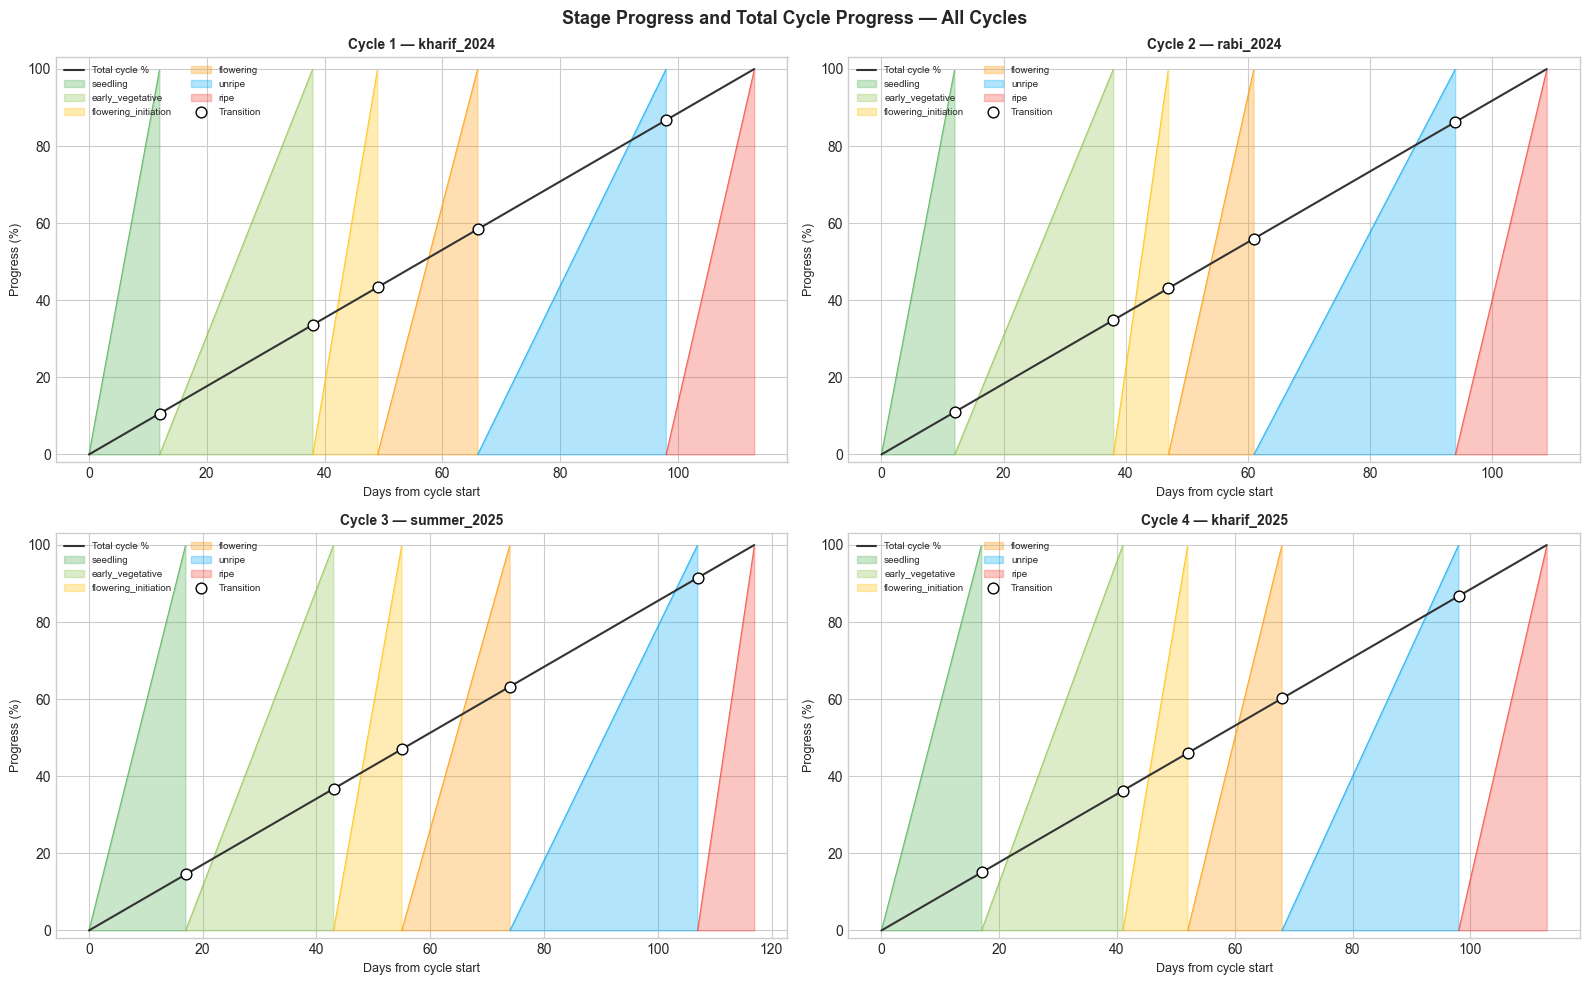

✅ Plot F7 saved.


In [63]:
# ── F7: Stage progress % and total cycle progress % over time (one cycle shown)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for plot_idx, cyc in enumerate(CYCLES):
    ax = axes[plot_idx // 2][plot_idx % 2]
    cyc_df = final_df[final_df["cycle_id"] == cyc["cycle_id"]].copy()
    cyc_df = cyc_df.sort_values("timestamp")

    # Total cycle progress line
    ax.plot(cyc_df["days_from_cycle_start"], cyc_df["total_cycle_progress_pct"],
            color="#333333", lw=1.5, zorder=5, label="Total cycle %")

    # Shade each stage
    for sp in cyc["stage_plan"]:
        mask = cyc_df["stage_name"] == sp["stage_name"]
        if mask.any():
            x = cyc_df.loc[mask, "days_from_cycle_start"]
            y = cyc_df.loc[mask, "stage_progress_pct"]
            color = STAGE_COLORS.get(sp["stage_name"], "#aaaaaa")
            ax.fill_between(x, y, alpha=0.3, color=color,
                            label=sp["stage_name"])
            ax.plot(x, y, color=color, lw=0.8, alpha=0.8)

    # Transition markers
    trans_rows = cyc_df[cyc_df["is_stage_transition"]]
    if not trans_rows.empty:
        ax.scatter(trans_rows["days_from_cycle_start"],
                   trans_rows["total_cycle_progress_pct"],
                   s=60, zorder=10, color="white",
                   edgecolors="black", linewidth=1, label="Transition")

    ax.set_xlabel("Days from cycle start", fontsize=9)
    ax.set_ylabel("Progress (%)", fontsize=9)
    ax.set_ylim(-2, 103)
    ax.set_title(f"Cycle {cyc['cycle_id']} — {cyc['label']}", fontsize=10, fontweight="bold")
    ax.legend(loc="upper left", fontsize=7, ncol=2)

plt.suptitle("Stage Progress and Total Cycle Progress — All Cycles",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "F7_cycle_progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot F7 saved.")

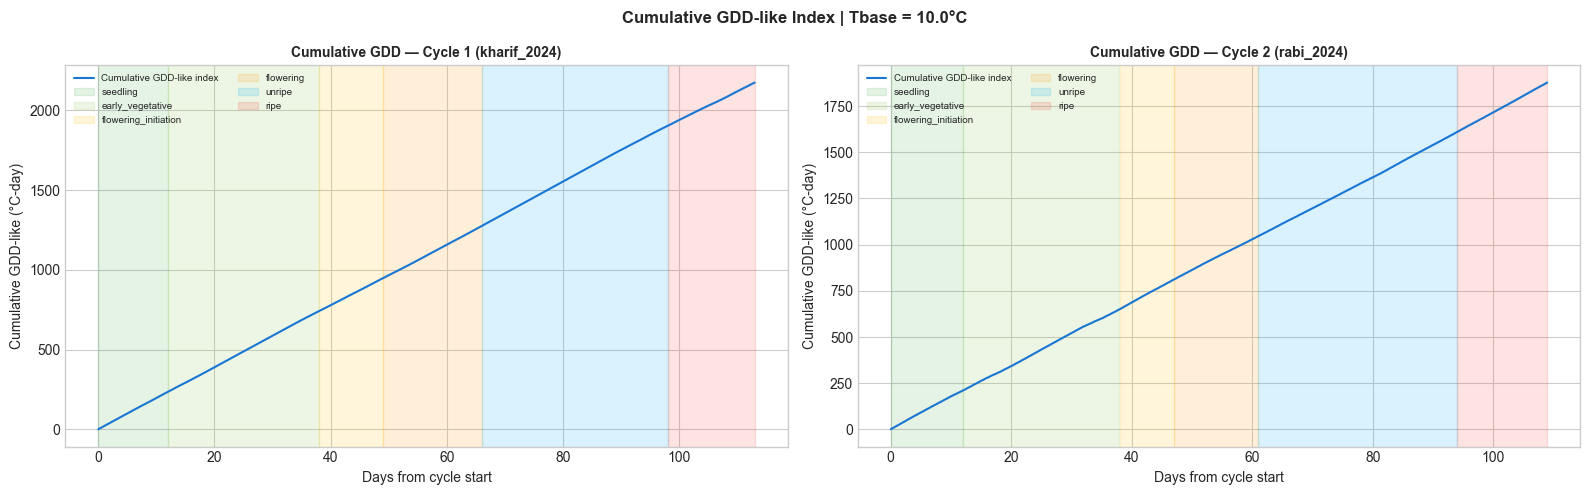

✅ Plot F8 saved.


In [64]:
# ── F8: Cumulative GDD-like index per cycle ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for plot_idx, cyc in enumerate(CYCLES[:2]):
    ax = axes[plot_idx]
    cyc_df = final_df[final_df["cycle_id"] == cyc["cycle_id"]].sort_values("timestamp")
    
    ax.plot(cyc_df["days_from_cycle_start"], cyc_df["cumulative_gdd_like_index"],
            color="#1976D2", lw=1.5, label="Cumulative GDD-like index")

    # Stage shading
    for sp in cyc["stage_plan"]:
        mask = cyc_df["stage_name"] == sp["stage_name"]
        if mask.any():
            x = cyc_df.loc[mask, "days_from_cycle_start"]
            ax.axvspan(x.min(), x.max(),
                       alpha=0.15,
                       color=STAGE_COLORS.get(sp["stage_name"], "#ccc"),
                       label=sp["stage_name"])

    ax.set_title(f"Cumulative GDD — Cycle {cyc['cycle_id']} ({cyc['label']})",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Days from cycle start")
    ax.set_ylabel("Cumulative GDD-like (°C-day)")
    ax.legend(fontsize=7, ncol=2, loc="upper left")

plt.suptitle(f"Cumulative GDD-like Index | Tbase = {CONFIG['gdd_tbase']}°C",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "F8_cumulative_gdd.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot F8 saved.")

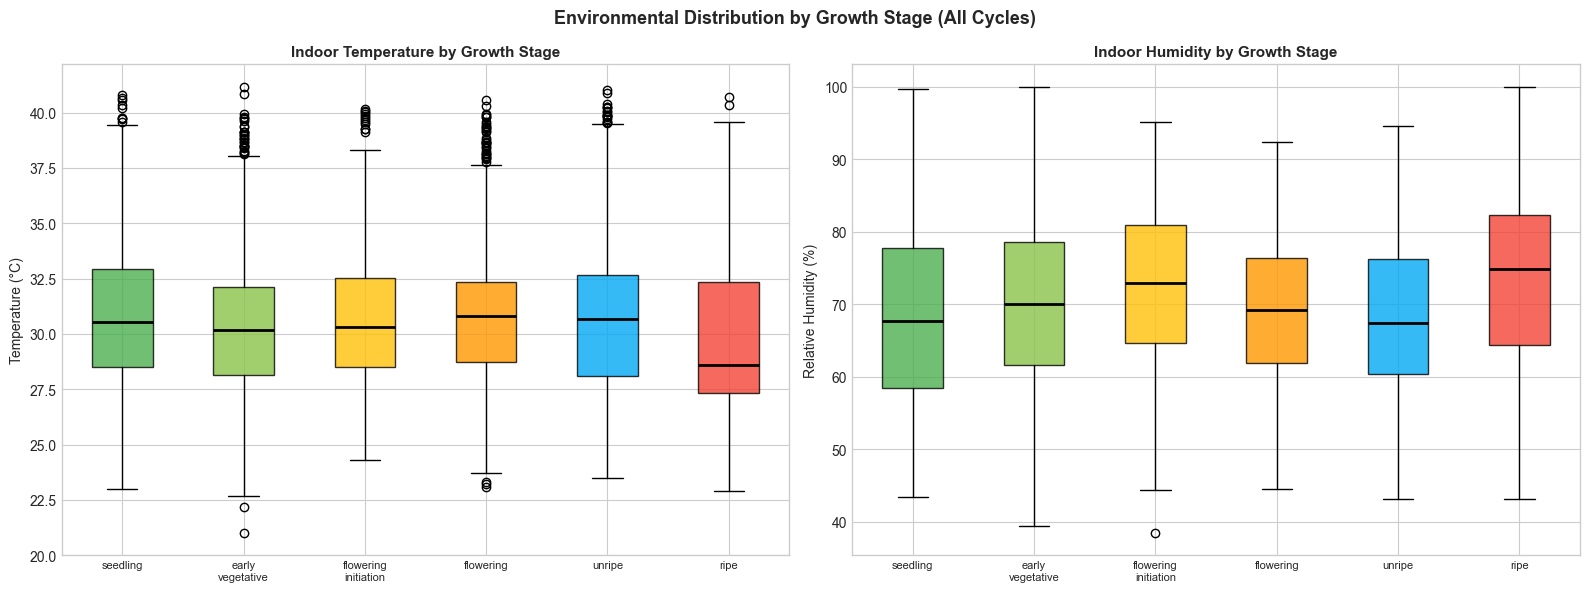

✅ Plot F9 saved.


In [65]:
# ── F9: Temperature and humidity distribution by stage (box plots) ──────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

stage_order = CONFIG["stages"]
colors_list = [STAGE_COLORS[s] for s in stage_order]

# Downsample for speed (1 in 6 = every 6 hours)
sample_df = final_df.iloc[::6].copy()

temp_data    = [sample_df.loc[sample_df["stage_name"] == s, "indoor_temp"].dropna().values
                for s in stage_order]
humidity_data = [sample_df.loc[sample_df["stage_name"] == s, "indoor_humidity"].dropna().values
                 for s in stage_order]

bp1 = ax1.boxplot(temp_data, labels=[s.replace("_", "\n") for s in stage_order],
                  patch_artist=True, medianprops={"color": "black", "lw": 2})
for patch, color in zip(bp1["boxes"], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax1.set_title("Indoor Temperature by Growth Stage", fontsize=11, fontweight="bold")
ax1.set_ylabel("Temperature (°C)")
ax1.tick_params(axis="x", labelsize=8)

bp2 = ax2.boxplot(humidity_data, labels=[s.replace("_", "\n") for s in stage_order],
                  patch_artist=True, medianprops={"color": "black", "lw": 2})
for patch, color in zip(bp2["boxes"], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax2.set_title("Indoor Humidity by Growth Stage", fontsize=11, fontweight="bold")
ax2.set_ylabel("Relative Humidity (%)")
ax2.tick_params(axis="x", labelsize=8)

plt.suptitle("Environmental Distribution by Growth Stage (All Cycles)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "F9_env_distributions_by_stage.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot F9 saved.")

In [66]:
# ── F10: Sample rows from the final dataset ──────────────────────────────────
print("=" * 60)
print("F10 — Sample rows from final dataset")
print("=" * 60)
display_cols = [
    "timestamp", "cycle_id", "cycle_label",
    "days_from_cycle_start", "stage_name", "stage_index",
    "stage_progress_pct", "total_cycle_progress_pct",
    "estimated_days_to_next_stage", "is_stage_transition",
    "indoor_temp", "indoor_humidity", "vpd",
]
display_cols = [c for c in display_cols if c in final_df.columns]
print(final_df[display_cols].head(10).to_string(index=False))

F10 — Sample rows from final dataset
          timestamp  cycle_id cycle_label  days_from_cycle_start stage_name  stage_index  stage_progress_pct  total_cycle_progress_pct  estimated_days_to_next_stage  is_stage_transition  indoor_temp  indoor_humidity    vpd
2024-07-01 00:00:00         1 kharif_2024                 0.0000   seedling            0              0.0000                    0.0000                       12.0000                False      29.0022          75.9296 0.9643
2024-07-01 01:00:00         1 kharif_2024                 0.0417   seedling            0              0.3470                    0.0370                       11.9583                False      27.8019          70.8301 1.0899
2024-07-01 02:00:00         1 kharif_2024                 0.0833   seedling            0              0.6940                    0.0740                       11.9167                False      28.2787          70.0355 1.1511
2024-07-01 03:00:00         1 kharif_2024                 0.1250   seed

---
## Section G — Export Files and Usage Notes

In [67]:
# ── G1: Build cycle summary table ────────────────────────────────────────────
cycle_summary_rows = []
for cyc in CYCLES:
    row = {
        "cycle_id":      cyc["cycle_id"],
        "cycle_label":   cyc["label"],
        "season_window": cyc["season_window"],
        "cycle_start":   cyc["cycle_start"].date(),
        "cycle_end":     cyc["cycle_end"].date(),
        "total_days":    cyc["total_days"],
    }
    for stage in CONFIG["stages"]:
        row[f"days_{stage}"] = cyc["stage_durations"][stage]
    # Row count from final_df
    row["total_hourly_rows"] = int((final_df["cycle_id"] == cyc["cycle_id"]).sum())
    cycle_summary_rows.append(row)

cycle_summary_df = pd.DataFrame(cycle_summary_rows)
print("Cycle Summary Table:")
print(cycle_summary_df.to_string(index=False))

Cycle Summary Table:
 cycle_id cycle_label         season_window cycle_start  cycle_end  total_days  days_seedling  days_early_vegetative  days_flowering_initiation  days_flowering  days_unripe  days_ripe  total_hourly_rows
        1 kharif_2024 Kharif (Jun–Jul 2024)  2024-07-01 2024-10-22         113             12                     26                         11              17           32         15               2712
        2   rabi_2024   Rabi (Oct–Nov 2024)  2024-11-10 2025-02-27         109             12                     26                          9              14           33         15               2616
        3 summer_2025 Summer (Feb–Mar 2025)  2025-03-05 2025-06-30         117             17                     26                         12              19           33         10               2808
        4 kharif_2025 Kharif (Jun–Jul 2025)  2025-07-01 2025-10-22         113             17                     24                         11              16        

In [68]:
# ── G2: Build stage summary table ─────────────────────────────────────────
env_stat_cols = [c for c in ["indoor_temp", "indoor_humidity", "vpd", "solarradiation"]
                 if c in final_df.columns]

stage_summary_df = (
    final_df.groupby(["cycle_id", "stage_index", "stage_name"])
    .agg(
        hourly_rows      = ("timestamp", "count"),
        start_timestamp  = ("timestamp", "min"),
        end_timestamp    = ("timestamp", "max"),
        actual_days      = ("days_in_current_stage", "max"),
        max_stage_prog   = ("stage_progress_pct", "max"),
        mean_gdd         = ("cumulative_gdd_like_index", "mean"),
        **{f"mean_{c}": (c, "mean") for c in env_stat_cols},
        **{f"std_{c}":  (c, "std")  for c in env_stat_cols},
    )
    .reset_index()
    .sort_values(["cycle_id", "stage_index"])
    .round(4)
)

print("Stage Summary Table (first 12 rows):")
print(stage_summary_df.head(12).to_string(index=False))

Stage Summary Table (first 12 rows):
 cycle_id  stage_index           stage_name  hourly_rows start_timestamp       end_timestamp  actual_days  max_stage_prog  mean_gdd  mean_indoor_temp  mean_indoor_humidity  mean_vpd  mean_solarradiation  std_indoor_temp  std_indoor_humidity  std_vpd  std_solarradiation
        1            0             seedling          288      2024-07-01 2024-07-12 23:00:00      11.9583         99.6530  118.3672           32.0498               67.2064    1.6391              65.2206           3.2638               7.3374   0.6438             82.4533
        1            1     early_vegetative          624      2024-07-13 2024-08-07 23:00:00      25.9583         99.8400  488.2756           31.7585               64.8709    1.7331              60.3473           3.2563               8.9351   0.7242             77.5785
        1            2 flowering_initiation          264      2024-08-08 2024-08-18 23:00:00      10.9583         99.6210  844.2913           30.3257    

In [69]:
# ── G3: Build metadata JSON ──────────────────────────────────────────────────
def _serialize(obj):
    """Convert numpy/pandas types for JSON serialization."""
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    if isinstance(obj, pd.Timestamp):
        return str(obj)
    return str(obj)


metadata = {
    "project":                CONFIG["project"],
    "location":               CONFIG["location"],
    "crop":                   CONFIG["crop"],
    "greenhouse_system":      CONFIG["system"],
    "notebook_name":          "tomato_growth_progression_synthetic_dataset.ipynb",
    "created_on":             datetime.now().isoformat(timespec="seconds"),
    "source_files": {
        "2024": str(RAW_2024),
        "2025": str(RAW_2025),
    },
    "data_years":             CONFIG["data_years"],
    "environmental_columns_used": env_cols_present,
    "stages_ordered":         CONFIG["stages"],
    "stage_index_map":        CONFIG["stage_index_map"],
    "stage_duration_ranges_days": CONFIG["stage_duration_ranges_days"],
    "gdd_tbase_celsius":      CONFIG["gdd_tbase"],
    "gdd_topt_celsius":       CONFIG["gdd_topt"],
    "temp_rolling_hours":     CONFIG["temp_rolling_hours"],
    "humidity_rolling_hours": CONFIG["humidity_rolling_hours"],
    "cycles": [
        {
            "cycle_id":       cyc["cycle_id"],
            "label":          cyc["label"],
            "season_window":  cyc["season_window"],
            "cycle_start":    str(cyc["cycle_start"].date()),
            "cycle_end":      str(cyc["cycle_end"].date()),
            "total_days":     cyc["total_days"],
            "stage_durations_days": cyc["stage_durations"],
        }
        for cyc in CYCLES
    ],
    "total_hourly_rows":       int(len(final_df)),
    "date_coverage": {
        "earliest_timestamp": str(final_df["timestamp"].min()),
        "latest_timestamp":   str(final_df["timestamp"].max()),
    },
    "output_files": {
        "hourly_dataset":   str(OUT_HOURLY),
        "cycle_summary":    str(OUT_CYCLE_SUM),
        "stage_summary":    str(OUT_STAGE_SUM),
        "metadata_json":    str(OUT_METADATA),
    },
    "column_groups": {
        "identity":    IDENTITY_COLS,
        "time":        TIME_COLS,
        "progression": PROGRESSION_COLS,
        "environment": ENV_BASE_COLS,
        "engineered":  ENG_COLS,
    },
    "label_rules": {
        "stage_order_is_fixed":       True,
        "backward_jumps_allowed":     False,
        "all_six_stages_per_cycle":   True,
        "cycle_ends_at_ripe":         True,
        "real_or_synthetic_flag":     "synthetic",
    },
    "agronomic_notes": [
        "Cultivation windows selected for Dindigul, Tamil Nadu based on "
        "Kharif (Jun-Jul), Rabi (Oct-Nov), and Summer (Feb-Mar) tomato planting seasons.",
        "Stage durations drawn randomly from agronomically defensible ranges; "
        "different per cycle to avoid artificial uniformity.",
        "Environmental backbone is the actual hourly greenhouse time-series "
        "from 2024 and 2025 — no synthetic random noise.",
        "Cumulative GDD-like index uses Tbase=10°C, Topt=30°C, "
        "hourly contribution = max(0, min(T,Topt)-Tbase)/24.",
        "Suitable for sequential ML models (LSTM, TCN, GRU) and progression "
        "regression/classification tasks.",
    ],
}

print("Metadata keys:", list(metadata.keys()))
print(f"\nCycles captured: {len(metadata['cycles'])}")

Metadata keys: ['project', 'location', 'crop', 'greenhouse_system', 'notebook_name', 'created_on', 'source_files', 'data_years', 'environmental_columns_used', 'stages_ordered', 'stage_index_map', 'stage_duration_ranges_days', 'gdd_tbase_celsius', 'gdd_topt_celsius', 'temp_rolling_hours', 'humidity_rolling_hours', 'cycles', 'total_hourly_rows', 'date_coverage', 'output_files', 'column_groups', 'label_rules', 'agronomic_notes']

Cycles captured: 4


In [70]:
# ── G4: Write all output files ───────────────────────────────────────────────
# 1. Full hourly synthetic dataset
final_df.to_csv(OUT_HOURLY, index=False)
print(f"✅ 1. Saved hourly dataset     → {OUT_HOURLY}")
print(f"      Rows: {len(final_df):,}  | Cols: {len(final_df.columns)}")

# 2. Cycle summary
cycle_summary_df.to_csv(OUT_CYCLE_SUM, index=False)
print(f"\n✅ 2. Saved cycle summary      → {OUT_CYCLE_SUM}")
print(f"      Rows: {len(cycle_summary_df)}")

# 3. Stage summary
stage_summary_df.to_csv(OUT_STAGE_SUM, index=False)
print(f"\n✅ 3. Saved stage summary      → {OUT_STAGE_SUM}")
print(f"      Rows: {len(stage_summary_df)}")

# 4. Metadata JSON
with open(OUT_METADATA, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, default=_serialize)
print(f"\n✅ 4. Saved metadata JSON      → {OUT_METADATA}")

print("\n" + "=" * 60)
print("All output files written successfully.")
print("=" * 60)

✅ 1. Saved hourly dataset     → E:\AgriTwin-GH\data\processed\Grwoth Progression\tomato_growth_progression_synthetic_hourly.csv
      Rows: 10,848  | Cols: 37

✅ 2. Saved cycle summary      → E:\AgriTwin-GH\data\processed\Grwoth Progression\tomato_growth_progression_cycle_summary.csv
      Rows: 4

✅ 3. Saved stage summary      → E:\AgriTwin-GH\data\processed\Grwoth Progression\tomato_growth_progression_stage_summary.csv
      Rows: 24

✅ 4. Saved metadata JSON      → E:\AgriTwin-GH\data\processed\Grwoth Progression\tomato_growth_progression_metadata.json

All output files written successfully.


In [71]:
# ── G5: Final completion report ──────────────────────────────────────────────
stage_dist_final = (
    final_df.groupby(["stage_index", "stage_name"])["timestamp"]
    .count()
    .reset_index()
    .rename(columns={"timestamp": "rows"})
    .sort_values("stage_index")
)
stage_dist_final["pct"] = (stage_dist_final["rows"] / len(final_df) * 100).round(2)

print("=" * 65)
print("  ✅  NOTEBOOK OBJECTIVE COMPLETED — AgriTwin-GH")
print("=" * 65)
print()
print("  📋  Description:")
print("      Season-aware, real-time-style synthetic tomato growth")
print("      progression dataset for Dindigul greenhouse, built from")
print("      actual 2024–2025 hourly environmental time-series data.")
print()
print("  📊  Dataset Statistics:")
print(f"      Total rows      : {len(final_df):,}")
print(f"      Total columns   : {len(final_df.columns)}")
print(f"      Cycle count     : {final_df['cycle_id'].nunique()}")
print(f"      Date coverage   : {final_df['timestamp'].min().date()}  →  "
      f"{final_df['timestamp'].max().date()}")
print()
print("  🌱  Stage Distribution:")
for _, row in stage_dist_final.iterrows():
    bar = "█" * int(row["pct"] / 2)
    print(f"      [{int(row['stage_index'])}] {row['stage_name']:<22}  "
          f"{row['rows']:>6,} rows  ({row['pct']:>5.1f}%)  {bar}")
print()
print("  📁  Files Saved:")
print(f"      {OUT_HOURLY}")
print(f"      {OUT_CYCLE_SUM}")
print(f"      {OUT_STAGE_SUM}")
print(f"      {OUT_METADATA}")
print()
print("  🔬  How to use this dataset:")
print()
print("      CLASSIFICATION  → Use (stage_name / stage_index) as the target.")
print("                        Features: all environmental + time + progression cols.")
print("                        Suitable for: RF, XGBoost, CNN-1D, LSTM classifiers.")
print()
print("      REGRESSION      → Use (stage_progress_pct, total_cycle_progress_pct,")
print("                        estimated_days_to_next_stage) as regression targets.")
print("                        Useful for real-time 'how far along' estimation.")
print()
print("      SEQUENCE MODELS → Use cycle_id to group sequences. Feed hours_in_stage,")
print("                        cumulative_gdd_like_index, env., and rolling means")
print("                        into LSTM / TCN / GRU for progression prediction.")
print()
print("      TRAIN/VAL/TEST  → Split by cycle_id (e.g., cycle 1–2 → train,")
print("                        cycle 3 → val, cycle 4 → test) to prevent")
print("                        temporal data leakage.")
print()
print("=" * 65)

  ✅  NOTEBOOK OBJECTIVE COMPLETED — AgriTwin-GH

  📋  Description:
      Season-aware, real-time-style synthetic tomato growth
      progression dataset for Dindigul greenhouse, built from
      actual 2024–2025 hourly environmental time-series data.

  📊  Dataset Statistics:
      Total rows      : 10,848
      Total columns   : 37
      Cycle count     : 4
      Date coverage   : 2024-07-01  →  2025-10-21

  🌱  Stage Distribution:
      [0] seedling                 1,392 rows  ( 12.8%)  ██████
      [1] early_vegetative         2,448 rows  ( 22.6%)  ███████████
      [2] flowering_initiation     1,032 rows  (  9.5%)  ████
      [3] flowering                1,584 rows  ( 14.6%)  ███████
      [4] unripe                   3,072 rows  ( 28.3%)  ██████████████
      [5] ripe                     1,320 rows  ( 12.2%)  ██████

  📁  Files Saved:
      E:\AgriTwin-GH\data\processed\Grwoth Progression\tomato_growth_progression_synthetic_hourly.csv
      E:\AgriTwin-GH\data\processed\Grwoth Pro